In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

In [3]:
df = pd.read_csv("cleaned_jobs.csv")

print("Shape:", df.shape)
df.head()

Shape: (12119, 11)


,job_title,company,location,description,search_role,description_length,description_word_count,job_text,created_year,created_month,created_day
0,Data Scientist,EXL,India,Advanced Analytics & Data Science Execution: L...,Data Scientist,500,64,Data Scientist Advanced Analytics & Data Scien...,2026,9,2
1,Data Scientist,Infosys Finacle,"Bangalore, Karnataka",Job Title: Data Scientist and Senior Data Scie...,Data Scientist,500,81,Data Scientist Job Title: Data Scientist and S...,2026,9,9
2,Data Scientist,Tata Consultancy Services,"Bangalore, Karnataka",TCS has been a great pioneer in feeding the fi...,Data Scientist,500,87,Data Scientist TCS has been a great pioneer in...,2026,9,4
3,Data Scientist,Atain,India,Data Scientist Location: Remote – India Experi...,Data Scientist,500,74,Data Scientist Data Scientist Location: Remote...,2026,9,1
4,Data Scientist,AB InBev GCC India,"Bangalore, Karnataka",Dreaming big is in our DNA. It’s who we are as...,Data Scientist,500,88,Data Scientist Dreaming big is in our DNA. It’...,2026,9,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12119 entries, 0 to 12118
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   job_title               12119 non-null  object
 1   company                 12119 non-null  object
 2   location                12119 non-null  object
 3   description             12119 non-null  object
 4   search_role             12119 non-null  object
 5   description_length      12119 non-null  int64 
 6   description_word_count  12119 non-null  int64 
 7   job_text                12119 non-null  object
 8   created_year            12119 non-null  int64 
 9   created_month           12119 non-null  int64 
 10  created_day             12119 non-null  int64 
dtypes: int64(5), object(6)
memory usage: 1.0+ MB


In [5]:
df.isnull().sum()

job_title                 0
company                   0
location                  0
description               0
search_role               0
description_length        0
description_word_count    0
job_text                  0
created_year              0
created_month             0
created_day               0
dtype: int64

In [7]:
X = df["job_text"]
y = df["search_role"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (12119,)
y shape: (12119,)


In [8]:
print("\nNumber of classes:", y.nunique())
print("\nClasses:")
print(y.unique())


Number of classes: 29

Classes:
['Data Scientist' 'Data Analyst' 'Machine Learning Engineer'
 'Data Engineer' 'Business Analyst' 'AI Engineer'
 'Business Intelligence Analyst' 'Software Developer' 'Software Engineer'
 'Frontend Developer' 'Backend Developer' 'Full Stack Developer'
 'Web Developer' 'Mobile App Developer' 'Cloud Engineer' 'DevOps Engineer'
 'Site Reliability Engineer' 'Cloud Architect' 'System Administrator'
 'Cybersecurity Engineer' 'Cybersecurity Analyst'
 'Information Security Analyst' 'Security Engineer' 'AI/ML Researcher'
 'NLP Engineer' 'Computer Vision Engineer' 'MLOps Engineer'
 'Data Architect' 'Solutions Architect']


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [10]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 9695
Testing samples: 2424


In [11]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=10000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [12]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (9695, 10000)
Testing TF-IDF shape: (2424, 10000)


# LOGISTIC REGRESSION

In [14]:
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [15]:
y_pred_log = log_model.predict(X_test_tfidf)

In [16]:
log_accuracy = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:",
      round(log_accuracy, 4))

Logistic Regression Accuracy: 0.7752


In [17]:
print(classification_report(y_test, y_pred_log))

                               precision    recall  f1-score   support

                  AI Engineer       0.69      0.79      0.73       100
             AI/ML Researcher       0.60      0.23      0.33        39
            Backend Developer       0.86      0.89      0.88       100
             Business Analyst       0.87      0.88      0.88       100
Business Intelligence Analyst       1.00      0.59      0.74        34
              Cloud Architect       0.72      0.69      0.70       100
               Cloud Engineer       0.85      0.74      0.79        99
     Computer Vision Engineer       0.80      0.48      0.60        25
        Cybersecurity Analyst       1.00      0.24      0.38        21
       Cybersecurity Engineer       0.56      0.69      0.62       100
                 Data Analyst       0.91      0.86      0.88       100
               Data Architect       0.83      0.77      0.80       100
                Data Engineer       0.63      0.84      0.72       100
     

# NAIVE BAYES

In [20]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [21]:
y_pred_nb = nb_model.predict(X_test_tfidf)
nb_accuracy = accuracy_score(y_test, y_pred_nb)

In [22]:
print("Naive Bayes Accuracy:",
      round(nb_accuracy, 4))

Naive Bayes Accuracy: 0.6465


In [19]:
print(classification_report(y_test, y_pred_nb))

                               precision    recall  f1-score   support

                  AI Engineer       0.50      0.72      0.59       100
             AI/ML Researcher       1.00      0.03      0.05        39
            Backend Developer       0.68      0.83      0.75       100
             Business Analyst       0.70      0.80      0.75       100
Business Intelligence Analyst       1.00      0.12      0.21        34
              Cloud Architect       0.70      0.53      0.60       100
               Cloud Engineer       0.78      0.53      0.63        99
     Computer Vision Engineer       1.00      0.08      0.15        25
        Cybersecurity Analyst       0.00      0.00      0.00        21
       Cybersecurity Engineer       0.45      0.57      0.50       100
                 Data Analyst       0.67      0.82      0.74       100
               Data Architect       0.74      0.67      0.71       100
                Data Engineer       0.55      0.76      0.64       100
     

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# LINEAR SVM

In [23]:
svm_model = LinearSVC(
    random_state=42
)

In [24]:
svm_model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,42


In [25]:
y_pred_svm = svm_model.predict(X_test_tfidf)

In [26]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print("Linear SVM Accuracy:",
      round(svm_accuracy, 4))

Linear SVM Accuracy: 0.7768


# MODEL COMPARISON

In [27]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Linear SVM"
    ],
    "Accuracy": [
        log_accuracy,
        nb_accuracy,
        svm_accuracy
    ]
})

results.sort_values(
    "Accuracy",
    ascending=False
)

,Model,Accuracy
2,Linear SVM,0.776815
0,Logistic Regression,0.775165
1,Naive Bayes,0.646452


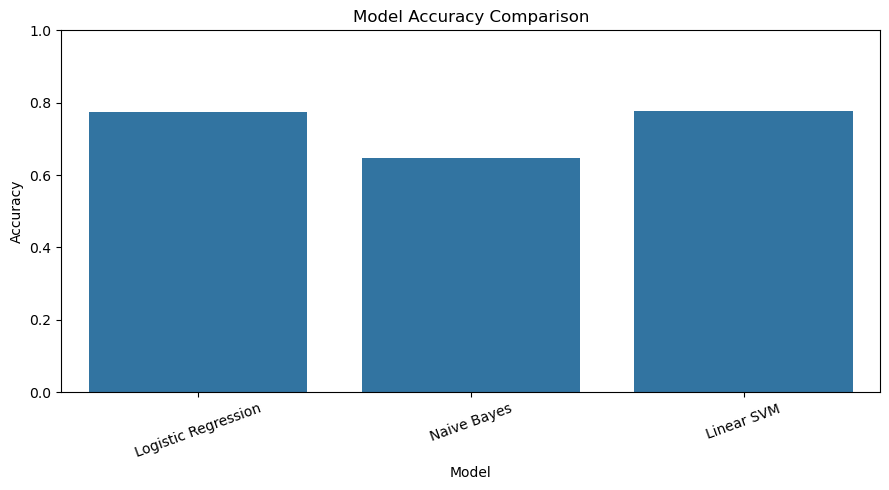

In [28]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

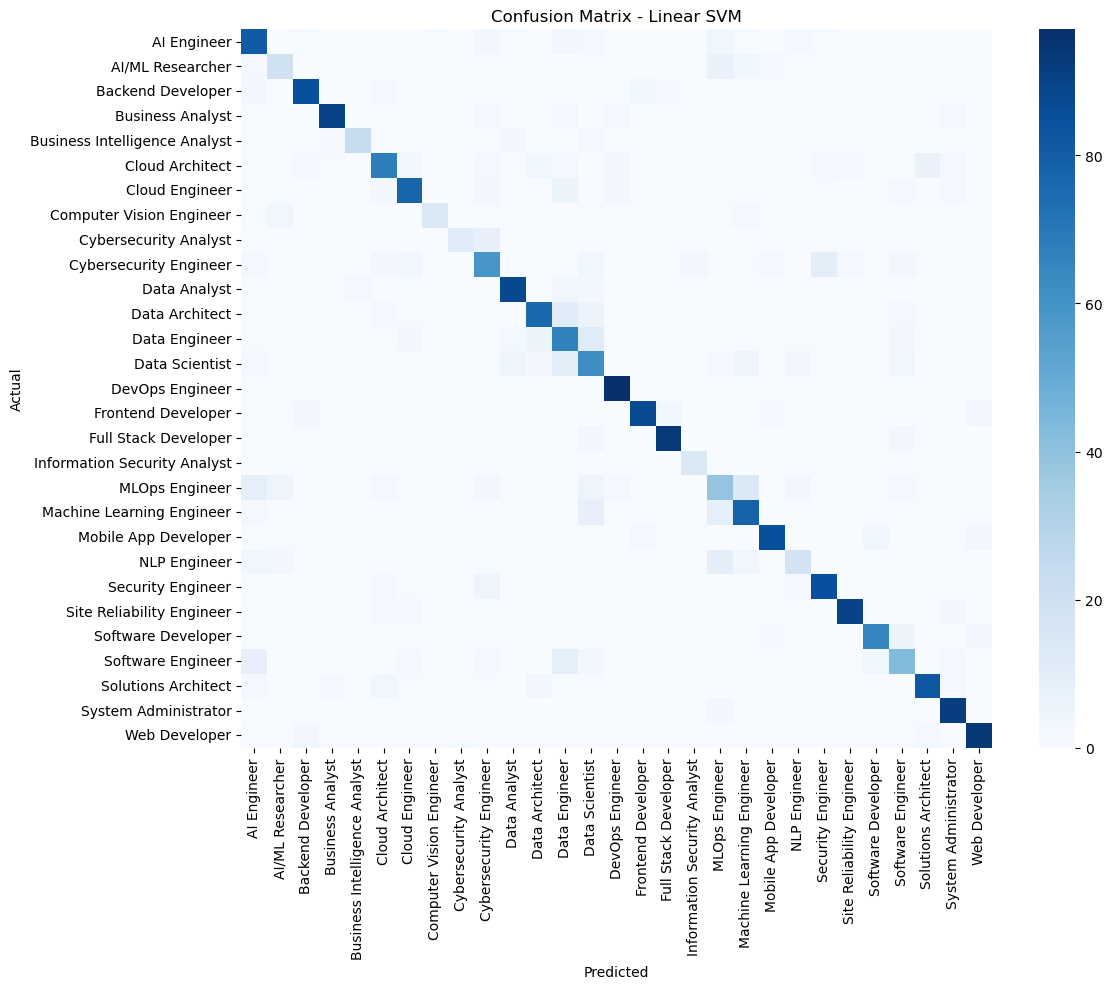

In [29]:
cm = confusion_matrix(
    y_test,
    y_pred_svm
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=svm_model.classes_,
    yticklabels=svm_model.classes_
)

plt.title("Confusion Matrix - Linear SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [30]:
final_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            max_features=10000,
            ngram_range=(1, 2)
        )
    ),
    (
        "model",
        LinearSVC(random_state=42)
    )
])

In [31]:
final_pipeline.fit(
    X_train,
    y_train
)

,steps,"[('tfidf', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [32]:
y_pred = final_pipeline.predict(X_test)

In [33]:
print("Final Model Accuracy:",
      accuracy_score(y_test, y_pred))

Final Model Accuracy: 0.7768151815181518


In [34]:
print(classification_report(y_test, y_pred))

                               precision    recall  f1-score   support

                  AI Engineer       0.68      0.81      0.74       100
             AI/ML Researcher       0.58      0.49      0.53        39
            Backend Developer       0.85      0.85      0.85       100
             Business Analyst       0.91      0.90      0.90       100
Business Intelligence Analyst       0.89      0.71      0.79        34
              Cloud Architect       0.76      0.68      0.72       100
               Cloud Engineer       0.79      0.78      0.78        99
     Computer Vision Engineer       0.82      0.56      0.67        25
        Cybersecurity Analyst       0.85      0.52      0.65        21
       Cybersecurity Engineer       0.61      0.59      0.60       100
                 Data Analyst       0.85      0.88      0.87       100
               Data Architect       0.79      0.76      0.78       100
                Data Engineer       0.58      0.67      0.62       100
     

In [ ]:
new_job = """
Python Developer with experience in machine learning,
Pandas, NumPy, Scikit-learn, SQL and data analysis.
"""

prediction = final_pipeline.predict([new_job])
print("Predicted Job Role:", prediction[0])

Predicted Job Role: Data Scientist


In [36]:
joblib.dump(
    final_pipeline,
    "job_market_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.
